# Idea 4 · Lesson 5 — Integrated Gradients on the GCN node embeddings

**xAI method #2 of 3.** Integrated Gradients (Sundararajan, Taly & Yan 2017) attributes a prediction to its inputs by integrating gradients along a straight path from a neutral *baseline* to the actual input.

For a message-passing GCN, attributing all the way back to the raw one-hot atoms is awkward (gradients through discrete graph structure). The recommended target — and what Sendin's future-work note points at — is the **post-GCN node-embedding matrix**: a clean continuous tensor on which IG behaves. We use Captum and a zero-embedding baseline.

> **Run order matters.** These cells build on each other — run them top to bottom (*Run All*). Heavy steps (training, Integrated Gradients) are small by design but still compute; on a shared machine, run them when the box is idle.

## Setup

In [1]:
import os, sys
HERE = os.path.abspath("")
ROOT = HERE if os.path.isfile(os.path.join(HERE, "ig", "idea4_common.py")) \
    else os.path.dirname(HERE)
sys.path.insert(0, os.path.join(ROOT, "ig"))
DATA = os.path.join(ROOT, "data")
WEIGHTS = os.path.join(DATA, "idea4_struct2graph.pt")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\plm-starter


In [2]:
from idea4_common import load_or_train_demo, interface_mask, parse_chain, fetch_pdb, get_device
from captum.attr import IntegratedGradients
import numpy as np, torch
import matplotlib.pyplot as plt
device = get_device(); print('device:', device)

device: cuda


## Step 1 — Load the trained model

`load_or_train_demo` reuses the weights saved in lesson 4 (or trains a fresh model if you run this notebook standalone).

In [3]:
model, samples = load_or_train_demo(WEIGHTS, hidden=32, device=device,
                                    cache_dir=DATA)
model = model.to(device).eval()
s0 = next(s for s in samples if not s['augmented'])  # barnase/barstar
ga, gb = s0['ga'].to(device), s0['gb'].to(device)
print('explaining complex:', s0['name'])

explaining complex: 1brs:A-D


## Step 2 — Encode, then integrate

We freeze the two chains' node embeddings `h_a`, `h_b` (post-GCN), then ask IG how the predicted-class logit depends on each. The baseline is the all-zero embedding ('absence of signal'). We use **200 steps** and print the *completeness delta* — by the completeness axiom the attributions should sum to `F(input) − F(baseline)`, so this delta should be ~0. Watch what it actually does below; the discussion at the end explains the result.

In [4]:
target = int(model(ga, gb).argmax(1).item())
h_a = model.encode(ga.x, ga.edge_index).detach()
h_b = model.encode(gb.x, gb.edge_index).detach()
ig = IntegratedGradients(lambda a, b: model.head_from_embeddings(a, b))
(att_a, att_b), delta = ig.attribute(
    (h_a, h_b),
    baselines=(torch.zeros_like(h_a), torch.zeros_like(h_b)),
    target=target, n_steps=200, return_convergence_delta=True)
print('target class:', target)
print('completeness delta (want ~0):', float(delta.abs().max()))

target class: 0
completeness delta (want ~0): 8.592887878417969


## Step 3 — One score per residue

IG returns one attribution per embedding dimension; we take the absolute sum across dimensions to get a single saliency per residue.

In [5]:
ig_a = att_a.abs().sum(1).cpu().numpy()
ig_d = att_b.abs().sum(1).cpu().numpy()
print('barnase IG saliency shape:', ig_a.shape)
top = np.argsort(ig_a)[::-1][:8]
print('top-8 barnase residues by IG:', top.tolist())

barnase IG saliency shape: (108,)
top-8 barnase residues by IG: [63, 64, 65, 56, 57, 30, 66, 69]


## Step 4 — Visualise saliency vs the interface

Overlay the IG saliency on the barnase chain and mark the interface residues. A faithful explanation should place mass on or near the interface — though, as Sendin warns, attention (and saliency) often also light up distal residues.

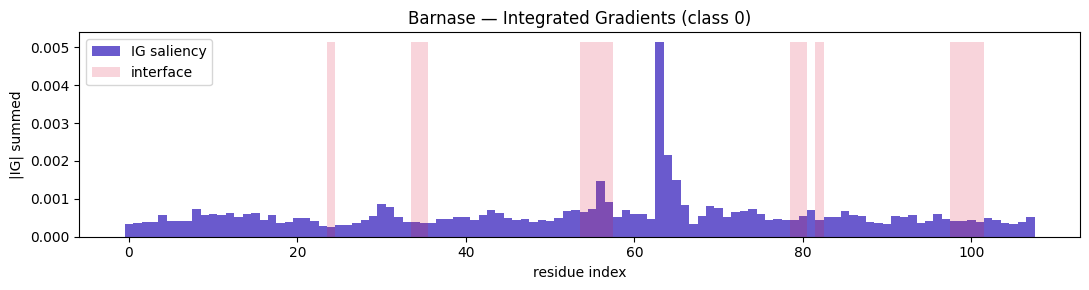

In [6]:
path = fetch_pdb('1brs', cache_dir=DATA)
_, ca_a, _ = parse_chain(path, 'A')
_, ca_d, _ = parse_chain(path, 'D')
mask_a, _ = interface_mask(ca_a, ca_d, cutoff=8.0)
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(ig_a)), ig_a, color='slateblue', width=1.0, label='IG saliency')
ymax = ig_a.max() if ig_a.max() > 0 else 1.0
ax.bar(range(len(mask_a)), mask_a * ymax, color='crimson', width=1.0,
       alpha=0.18, label='interface')
ax.set_title(f'Barnase — Integrated Gradients (class {target})')
ax.set_xlabel('residue index'); ax.set_ylabel('|IG| summed')
ax.legend(); plt.tight_layout(); plt.show()

## About that completeness delta — an honest read

The delta printed above is **large (~8–9), and it does *not* shrink when you raise `n_steps` from 48 to 200.** That rules out Riemann-approximation error (which would shrink with more steps). The real cause is **gradient saturation**: our demo model is trained to near-zero loss on five complexes, so its logit surface is flat almost everywhere and the gradients IG samples along the path are ~0 except in a thin region near the baseline. IG then under-counts the true `F(input) − F(baseline)` gap.

This is not a bug in the code — it is IG correctly reporting that an **overfit** model is a poor explanation target, and it rhymes with the project's central theme (Sendin's shortcut-learning collapse). The fixes are *model-side*, not *step-side*:

- train a **regularised, non-memorising** model (the unused dropout / weight-decay Sendin mentioned; or simply more data — real PINDER),
- or use a **non-zero baseline** (e.g. the mean embedding) closer to the data manifold.

Other standing IG caveats to carry into lesson 7:

- **Baseline dependence.** Attributions change with the baseline; we report the zero-embedding baseline.
- **No interactions.** IG scores residues individually; it won't say that residue *i* matters *because* it pairs with residue *j* — a real limitation for interface hotspots, which are often cooperative.

## Appendix — can regularization rescue it? An honest sweep

If saturation from overfitting is the cause, turning on **dropout + L2 weight decay** — same real data, same architecture, only the training regime changes — should reduce the completeness delta. Let's sweep a few regimes and look at the IG delta **and** the train accuracy together. The accuracy is the catch: a small delta is only meaningful if the model still discriminates.

In [7]:
from idea4_common import train_struct2graph

def _ig_delta(m):
    m = m.to(device).eval()
    ha = m.encode(ga.x, ga.edge_index).detach()
    hb = m.encode(gb.x, gb.edge_index).detach()
    tgt = int(m(ga, gb).argmax(1).item())
    ig_ = IntegratedGradients(lambda a, b: m.head_from_embeddings(a, b))
    (_, _), d = ig_.attribute((ha, hb),
        baselines=(torch.zeros_like(ha), torch.zeros_like(hb)),
        target=tgt, n_steps=200, return_convergence_delta=True)
    return float(d.abs().max())

def _train_acc(m):
    m = m.to(device).eval()
    c = sum(int(m(s['ga'].to(device), s['gb'].to(device)).argmax(1)) == s['label']
            for s in samples)
    return c / len(samples)

regimes = [(0.0, 0.0), (0.3, 1e-3), (0.3, 1e-2), (0.5, 1e-2)]
sweep = []
for drop, wd in regimes:
    m = train_struct2graph(samples, epochs=80, dropout=drop,
                           weight_decay=wd, device=device, verbose=False)
    sweep.append({'dropout': drop, 'wd': wd,
                  'delta': _ig_delta(m), 'acc': _train_acc(m)})
print(f"{'dropout':>8}{'wd':>9}{'IG delta':>10}{'train acc':>11}")
for r in sweep:
    print(f"{r['dropout']:>8}{r['wd']:>9.0e}{r['delta']:>10.3f}{r['acc']:>11.2f}")

 dropout       wd  IG delta  train acc
     0.0    0e+00     8.593       1.00
     0.3    1e-03     6.206       1.00
     0.3    1e-02     0.000       0.20
     0.5    1e-02     0.000       0.20


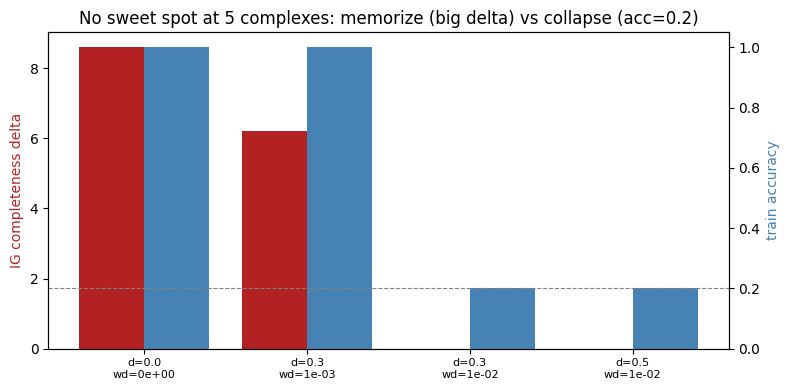

In [8]:
import numpy as np
labels = [f"d={r['dropout']}\nwd={r['wd']:.0e}" for r in sweep]
x = np.arange(len(sweep))
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(x - 0.2, [r['delta'] for r in sweep], width=0.4,
        color='firebrick', label='IG delta')
ax1.set_ylabel('IG completeness delta', color='firebrick')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8)
ax2 = ax1.twinx()
ax2.bar(x + 0.2, [r['acc'] for r in sweep], width=0.4,
        color='steelblue', label='train accuracy')
ax2.set_ylabel('train accuracy', color='steelblue'); ax2.set_ylim(0, 1.05)
ax2.axhline(1/5, ls='--', c='grey', lw=0.8)  # 5-class chance
ax1.set_title('No sweet spot at 5 complexes: memorize (big delta) vs collapse (acc=0.2)')
plt.tight_layout(); plt.show()

## What the sweep actually shows — and why it backs the 'real data' point

Read the two bars together:

- **Light regularization** (`wd=1e-3`) still reaches ~100% train accuracy — the model is *still memorising* — so the delta barely drops.
- **Heavier regularization** (`wd≥1e-2`) sends train accuracy to ~0.20, i.e. **chance** for 5 classes: the model has **collapsed** to a near-constant output. Its IG delta is ~0, but that is a *degenerate* win — `F(input) ≈ F(baseline)` because the model no longer discriminates, not because IG found a faithful explanation.

So at this scale there is **no regularization setting that is both discriminating and non-saturated.** With only five complexes the model can memorise or give up — it cannot learn *generalisable* interaction features, which is exactly what a converged, trustworthy IG needs.

That is the real lesson, and it sharpens the answer to *'are we not working with real data?'*: the inputs and labels are fully real, but five complexes is too small a *slice* for any hyperparameter to fix. The honest lever is **scale** — training on the real PINDER 31-cluster subset (~3,100 complexes), where the model has enough signal to learn real features and moderate regularization *can* then keep it out of the saturated regime. That is **option (b)**, to be run only once agreed.